In [5]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from sklearn.neighbors import NearestNeighbors
import scipy.optimize as opt
import scipy.io as sio
import matplotlib.pyplot as plt 
SANS_SERIF_FONTS = ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans']
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})


In [6]:
RawCat = np.loadtxt('../data/Hengill/raw/COSEISMIQ_catalogue')
RawCat[:, 8] = -RawCat[:, 8]  
CumulativeDailyVolumes = sio.loadmat('../data/Hengill/raw/CumulativeDailyVolumes.mat')['CumulativeDailyVolume']
DailyRates = sio.loadmat('../data/Hengill/raw/DailyRates.mat')['DailyRates']
DailyVolumes = sio.loadmat('../data/Hengill/raw/DailyVolumes.mat')['DailyVolumes']

In [7]:
times_num = sio.loadmat('../data/Hengill/raw/TimesVolumes_serial.mat', squeeze_me=True)['Times_num']
times = pd.to_datetime(times_num - 719529, unit='D') 
n_dates = len(times)

In [8]:
yr = RawCat[:, 0].astype(int)
mo = RawCat[:, 1].astype(int)
dy = RawCat[:, 2].astype(int)
hh = RawCat[:, 3].astype(int)
mm = RawCat[:, 4].astype(int)
ss = RawCat[:, 5].astype(int)

Cat_time = np.array([
    datetime(yr[i], mo[i], dy[i], hh[i], mm[i], ss[i])
    for i in range(len(yr))
])

LPstart = datetime(2018, 12, 1)
LPend = datetime(2020, 2, 1)
FPend = datetime(2021,2,1)

t_days = np.array([(t - LPstart).days + (t - LPstart).seconds/86400 for t in Cat_time])

# build a pandas DataFrame and keep a NumPy 'Cat' array for downstream cells
df = pd.DataFrame({
    't': t_days,
    'magnitude': RawCat[:, 6].astype(float),
    'latitude': RawCat[:, 7].astype(float),
    'longitude': RawCat[:, 8].astype(float),
    'depth': RawCat[:, 9].astype(float),
    'event_score': RawCat[:, 10].astype(float),
    'ts': Cat_time
})

In [9]:
# Active region & magnitude threshold
ActiveRegionLon = [-21.5, -21.25]
ActiveRegionLat = [63.98, 64.08]
Mc = 0.3

lat_min, lat_max = ActiveRegionLat
lon_min, lon_max = ActiveRegionLon

# filter events efficiently and avoid SettingWithCopyWarning
mask = (
    df['magnitude'].notna() &
    df['latitude'].between(lat_min, lat_max) &
    df['longitude'].between(lon_min, lon_max) &
    (df['event_score'] >= -5)
)
df = df.loc[mask].copy()

# sort and compute inter-event times (keep NaN for first event)
df.sort_values(by='t', inplace=True)
df.reset_index(drop=True, inplace=True)
df['dt'] = df['t'].diff()

# grid parameters
Gridgranularity = 0.005
dlon = dlat = float(Gridgranularity)

# compute integer grid dimensions (ceil to include boundary)
ncols = int((lon_max - lon_min) / dlon)
nrows = int((lat_max - lat_min) / dlat)

# compute cell indices robustly and clip to valid range
ix = np.floor((df['longitude'] - lon_min) / dlon).astype(int)
iy = np.floor((df['latitude']  - lat_min) / dlat).astype(int)

df['ix'] = ix.clip(0, ncols - 1)
df['iy'] = iy.clip(0, nrows - 1)

# number of time steps (rename to avoid shadowing built-in)
n_days = DailyRates.shape[1]

In [10]:
# df = df[df['magnitude']>=0.3]

In [11]:
int((lat_max - lat_min) / dlat)

20

In [12]:
Maprates = DailyRates.reshape((nrows, ncols,n_days))
Mapvolumes = DailyVolumes.reshape((nrows, ncols,n_days))
Mapcumvolumes = CumulativeDailyVolumes.reshape((nrows, ncols,n_days))

In [13]:
count = np.zeros(( nrows, ncols, n_dates))
for day_idx, day in enumerate(times):
    day_events = df[
        (df['ts'].dt.date == day.date())
    ]
    for _, event in day_events.iterrows():
        x_idx = int((event['latitude'] - ActiveRegionLat[0]) / Gridgranularity)
        y_idx = int((event['longitude'] - ActiveRegionLon[0]) / Gridgranularity)
        count[x_idx, y_idx, day_idx] += 1

In [14]:
count.shape,Mapcumvolumes.shape,Mapvolumes.shape,Maprates.shape

((20, 50, 794), (20, 50, 794), (20, 50, 794), (20, 50, 794))

In [15]:
import pandas as pd

summed = count.sum(axis=2)           # shape: (nrows, ncols)
mask = summed > 30
rows, cols = np.where(mask)          # rows -> axis0 索引, cols -> axis1 索引
values = summed[rows, cols]

result = pd.DataFrame({'axis0': rows, 'axis1': cols, 'sum': values})
result = result.sort_values('sum', ascending=False).reset_index(drop=True)
result

,axis0,axis1,sum
0,15,20,444.0
1,13,20,324.0
2,14,20,320.0
3,15,21,310.0
4,14,21,233.0
5,13,21,214.0
6,15,19,212.0
7,15,22,157.0
8,14,19,151.0
9,16,21,133.0


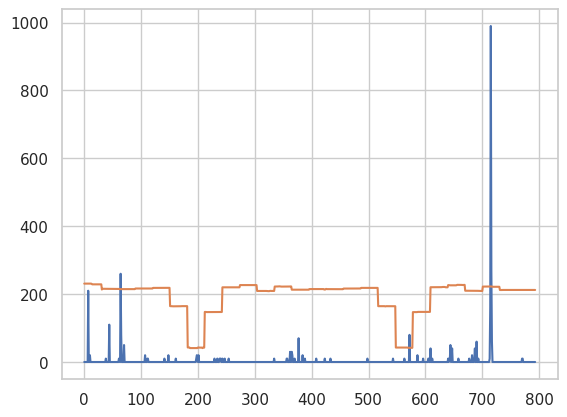

In [16]:
plt.plot(count[13,20,:]*10)
plt.plot(Mapvolumes[13,20,:])

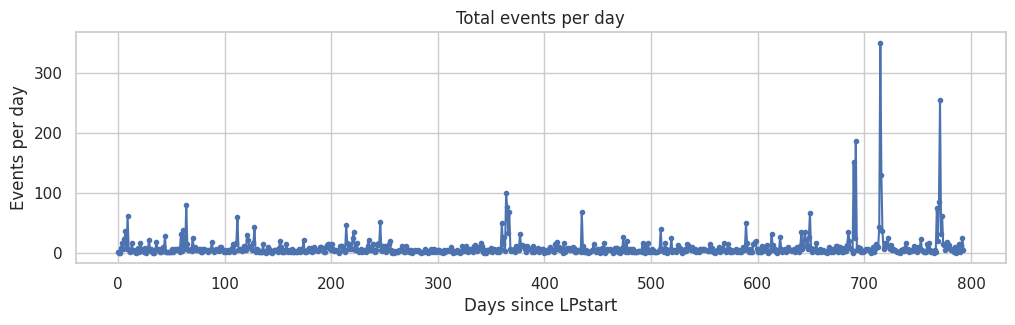

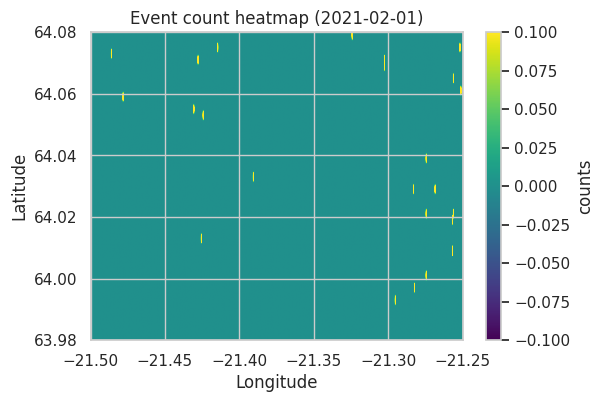

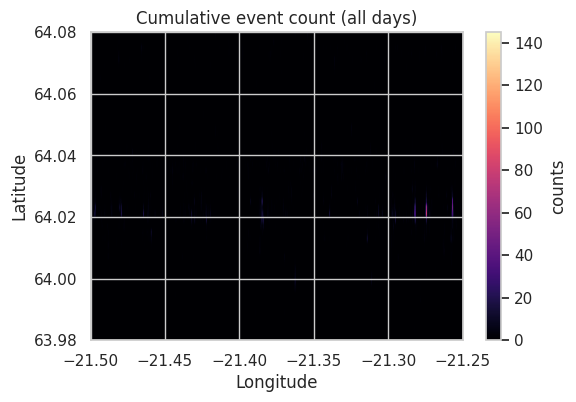

In [17]:
# visualize `count` (shape: [time, lat_bins, lon_bins])
length, n_lat, n_lon = count.shape

# 1) time series: total events per day
daily_totals = count.sum(axis=(0, 1))
days_since_LP = (times - LPstart) / np.timedelta64(1, 'D')

plt.figure(figsize=(12, 3))
plt.plot(days_since_LP, daily_totals, '-o', markersize=3)
plt.xlabel('Days since LPstart'); plt.ylabel('Events per day')
plt.title('Total events per day')
plt.grid(True)
plt.show()

# 2) snapshot heatmap for a chosen day (use an index or date)
day_idx = -1  # change to any integer in [0, length-1]
snap = count[day_idx]

extent = [ActiveRegionLon[0], ActiveRegionLon[1], ActiveRegionLat[0], ActiveRegionLat[1]]
vmax = np.percentile(count, 99)  # avoid extreme outliers in color scaling

plt.figure(figsize=(6, 4))
im = plt.imshow(snap, origin='lower', extent=extent, aspect='auto', vmin=0, vmax=vmax, cmap='viridis')
plt.title(f'Event count heatmap ({pd.to_datetime(times[day_idx]).date()})')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.colorbar(im, label='counts')
plt.show()

# 3) cumulative spatial map (all days)
cum = count.sum(axis=0)
plt.figure(figsize=(6, 4))
im = plt.imshow(cum, origin='lower', extent=extent, aspect='auto', cmap='magma')
plt.title('Cumulative event count (all days)')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.colorbar(im, label='counts')
plt.show()

# 4) (optional) animation — uncomment to run in the notebook
# from matplotlib import animation
# fig, ax = plt.subplots(figsize=(6,4))
# im = ax.imshow(count[0], origin='lower', extent=extent, vmin=0, vmax=vmax, cmap='viridis', aspect='auto')
# def update(i):
#     im.set_data(count[i])
#     ax.set_title(str(pd.to_datetime(times[i]).date()))
#     return [im]
# anim = animation.FuncAnimation(fig, update, frames=length, interval=150)
# from IPython.display import HTML
# HTML(anim.to_jshtml())

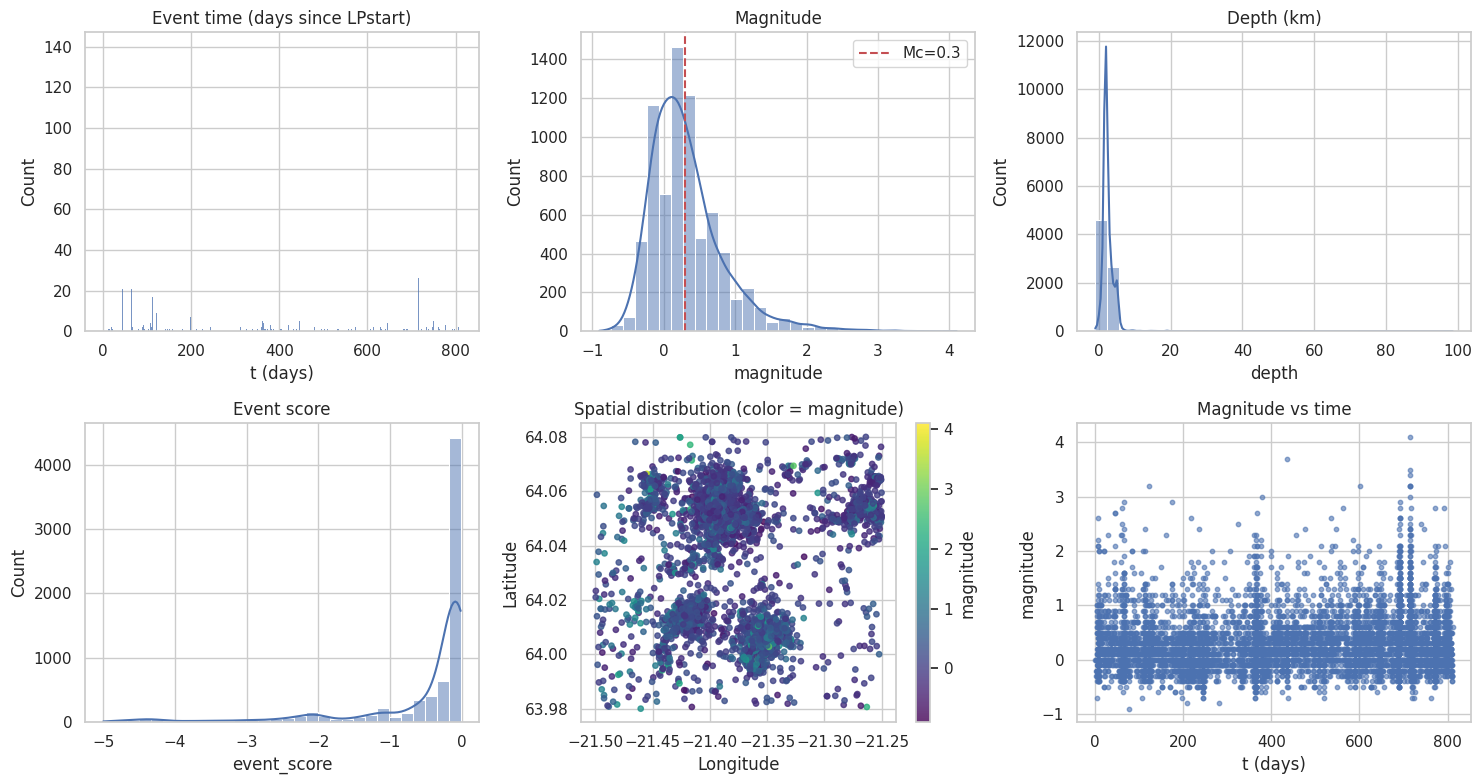

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(df['t'], bins=16000, kde=False, ax=axs[0, 0])
axs[0, 0].set_title('Event time (days since LPstart)')
axs[0, 0].set_xlabel('t (days)')

sns.histplot(df['magnitude'], bins=30, kde=True, ax=axs[0, 1])
axs[0, 1].axvline(Mc, color='r', linestyle='--', label=f'Mc={Mc}')
axs[0, 1].set_title('Magnitude')
axs[0, 1].legend()

sns.histplot(df['depth'], bins=30, kde=True, ax=axs[0, 2])
axs[0, 2].set_title('Depth (km)')


sns.histplot(df['event_score'], bins=30, kde=True, ax=axs[1, 0])
axs[1, 0].set_title('Event score')

sc = axs[1, 1].scatter(df['longitude'], df['latitude'], c=df['magnitude'], cmap='viridis', s=15, alpha=0.8)
axs[1, 1].set_title('Spatial distribution (color = magnitude)')
axs[1, 1].set_xlabel('Longitude')
axs[1, 1].set_ylabel('Latitude')
plt.colorbar(sc, ax=axs[1, 1], label='magnitude')

axs[1, 2].scatter(df['t'], df['magnitude'], s=10, alpha=0.6)
axs[1, 2].set_title('Magnitude vs time')
axs[1, 2].set_xlabel('t (days)')
axs[1, 2].set_ylabel('magnitude')

plt.tight_layout()
plt.show()

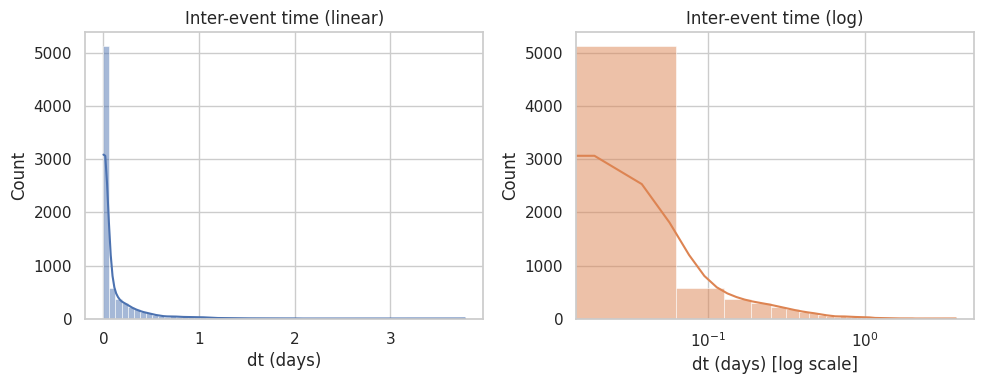

In [19]:
dt = df['dt']
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(dt, bins=60, kde=True, color='C0')
plt.xlabel('dt (days)')
plt.title('Inter-event time (linear)')

plt.subplot(1,2,2)
sns.histplot(dt, bins=60, kde=True, color='C1')
plt.xscale('log')
plt.xlabel('dt (days) [log scale]')
plt.title('Inter-event time (log)')

plt.tight_layout()
plt.show()

In [20]:
d = DailyVolumes/DailyRates
unique_values = np.unique(d)
print(unique_values[0],unique_values[1],unique_values[2])
print(unique_values)
CumulativeDailyVolumes = np.cumsum(DailyVolumes, axis=1)
d2 = CumulativeDailyVolumes/CumulativeDailyVolumes
unique_values2 = np.unique(d2)
print(unique_values2)

85.99999999999999 86.0 86.00000000000001
[86. 86. 86.]
[1.]


In [21]:
# from matplotlib import animation
# from IPython.display import HTML

# time_steps = Mapvolumes.shape[2]
# extent = [ActiveRegionLon[0], ActiveRegionLon[1], ActiveRegionLat[0], ActiveRegionLat[1]]
# vmin = np.nanpercentile(Mapvolumes, 0)
# vmax = np.nanpercentile(Mapvolumes, 99)
# total_cum = Mapvolumes.sum(axis=(0,1))
# plt.figure(figsize=(10,3))
# plt.plot(np.arange(time_steps), total_cum, '-o', markersize=3)
# plt.xlabel('day index')
# plt.ylabel('total cumulative volume')
# plt.title('Total cumulative volume vs time')
# plt.grid(True)
# plt.show()

# day0 = 0
# day_mid = time_steps // 2

# fig, axs = plt.subplots(1, 2, figsize=(12,5))
# im1 = axs[0].imshow(Mapvolumes[:, :, day0], origin='lower', extent=extent, vmin=vmin, vmax=vmax, aspect='auto', cmap='viridis')
# axs[0].set_title(f'Cumulative volume (day {day0})')
# axs[0].set_xlabel('Longitude'); axs[0].set_ylabel('Latitude')
# im2 = axs[1].imshow(Mapvolumes[:, :, day_mid], origin='lower', extent=extent, vmin=vmin, vmax=vmax, aspect='auto', cmap='viridis')
# axs[1].set_title(f'Cumulative volume (day {day_mid})')
# axs[1].set_xlabel('Longitude'); axs[1].set_ylabel('Latitude')
# fig.colorbar(im1, ax=axs.ravel().tolist(), label='cumulative volume')
# plt.tight_layout()
# plt.show()


# fig2, ax2 = plt.subplots(figsize=(6,5))
# im = ax2.imshow(Mapvolumes[:, :, 0], origin='lower', extent=extent, vmin=vmin, vmax=vmax, aspect='auto', cmap='viridis')
# cbar = fig2.colorbar(im, ax=ax2, label='cumulative volume')
# ax2.set_xlabel('Longitude'); ax2.set_ylabel('Latitude')

# def update(i):
#     im.set_data(Mapvolumes[:, :, i])
#     ax2.set_title(f'Cumulative volume (day {i})')
#     return [im]

# anim = animation.FuncAnimation(fig2, update, frames=time_steps, interval=200, blit=True)
# HTML(anim.to_jshtml())

In [22]:
import src.features.glob_rect_grid as grid
LonGMat,LatGMat,areamat,grid_vec_format=grid.GlobRectGrid([Gridgranularity,Gridgranularity],ActiveRegionLon,ActiveRegionLat)

In [23]:
df

,t,magnitude,latitude,longitude,depth,event_score,ts,dt,ix,iy
0,0.725313,0.0,64.01957,-21.40846,2.428,-1.068207,2018-12-01 17:24:27,NaN,18,7
1,3.045671,0.0,64.04870,-21.40343,1.854,-0.046209,2018-12-04 01:05:46,2.320359,19,13
2,3.086644,-0.3,64.05220,-21.38902,1.802,-0.121965,2018-12-04 02:04:46,0.040972,22,14
3,3.117083,0.0,64.05477,-21.26077,3.204,-0.103522,2018-12-04 02:48:36,0.030440,47,14
4,3.399815,-0.2,64.05339,-21.39156,2.103,-0.179062,2018-12-04 09:35:44,0.282731,21,14
...,...,...,...,...,...,...,...,...,...,...
7412,810.034479,-0.3,64.05018,-21.28278,4.010,-2.069386,2021-02-18 00:49:39,0.120116,43,14
7413,810.344884,0.5,64.02937,-21.49712,4.769,-2.804344,2021-02-18 08:16:38,0.310405,0,9
7414,810.513067,-0.2,64.05018,-21.39592,3.639,-0.121006,2021-02-18 12:18:49,0.168183,20,14
7415,810.514282,-0.1,64.04936,-21.40043,3.722,-0.306864,2021-02-18 12:20:34,0.001215,19,13


In [24]:
LonGMat.shape,LatGMat.shape,areamat.shape,grid_vec_format.shape

((20, 50), (20, 50), (20, 50), (1000, 3))

In [25]:
df_filtered = df[df['magnitude'] >= Mc].reset_index(drop=True)
df_train = df_filtered[df_filtered['ts'] < LPend].reset_index(drop=True)

In [26]:
from collections import defaultdict
grid_event_dict = defaultdict(list)
for _, row in df.iterrows():
    grid_event_dict[row["grid_id"]].append(row)

KeyError: 'grid_id'

In [ ]:
Volumes = Mapvolumes.sum(axis=(0,1))
Cumvolumes = Mapcumvolumes.sum(axis=(0,1))

In [ ]:
train_end_idx = np.where(times == LPend)[0][0]
days = np.array((times - LPstart) / np.timedelta64(1, 'D'))

In [ ]:
rate = dict()
rate['m_0'] = Mc
rate['t_b_s'] = days[:train_end_idx+1]
rate['dot_V_bs']=Volumes[:train_end_idx+1]
rate['m_0_m'] =Mc
rate['tot_V'] = Cumvolumes[train_end_idx]
rate['data_magn'] = df_train['magnitude'].values
rate['t_sbs'] = df_train['t'].values

In [ ]:
import src.features.b_ll as bl
bl.estimate_b_value(rate['data_magn'],rate['m_0'],10)

(1.067278447681823, -131.21341041817448)

In [ ]:
import src.features.si_ll as si
import importlib
importlib.reload(si)
import numpy as np
from scipy.optimize import minimize

initial_theta = [1, 1]  
result = minimize(lambda theta: si.log_lhood_comp(theta, rate), initial_theta, method='BFGS')

if result.success:
    optimized_theta = result.x
    print(f"Optimized theta: af = {optimized_theta[0]}, b = {optimized_theta[1]}")
else:
    print("Optimization failed:", result.message)


Optimized theta: af = -4.434022237072702, b = 1.0673062746449307


In [ ]:
af = optimized_theta[0]
b =  optimized_theta[1]
N_forecast = Volumes*10**(af - b*(Mc - rate['m_0']))

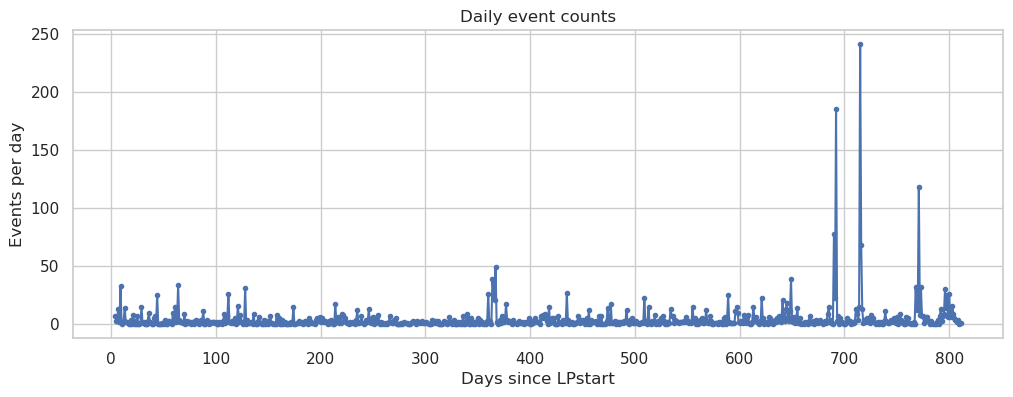

In [ ]:
daily_counts = df_filtered.groupby(df_filtered['ts'].dt.normalize()).size().sort_index()
date_index = pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq='D')
daily_counts = daily_counts.reindex(date_index, fill_value=0)
days_since_LP = (daily_counts.index - LPstart) / np.timedelta64(1, 'D')
plt.figure(figsize=(12,4))
plt.plot(days_since_LP, daily_counts.values, '-o', markersize=3)
plt.xlabel('Days since LPstart')
plt.ylabel('Events per day')
plt.title('Daily event counts')
plt.grid(True)
plt.show()